In [12]:
import os
import torch
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import glob
import yaml

In [13]:
dataset = "chat_bot_detection_912_ai_118_non_ai_v4.yolov12"
yaml_path = os.path.join(dataset, "data.yaml")

with open(yaml_path, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

data["train"] = "train/images"
data["val"] = "valid/images"
data.pop("test", None)

fixed_yaml = os.path.join(dataset, "data_fixed.yaml")
with open(fixed_yaml, "w", encoding="utf-8") as f:
    yaml.safe_dump(data, f, sort_keys=False)

print("Using YAML:", fixed_yaml)
print("Train:", data["train"], "- exists:", os.path.exists(os.path.join(dataset, data["train"])))
print("Val:", data["val"], "- exists:", os.path.exists(os.path.join(dataset, data["val"])))
print("Names:", data.get("names"))

Using YAML: chat_bot_detection_912_ai_118_non_ai_v4.yolov12\data_fixed.yaml
Train: train/images - exists: True
Val: valid/images - exists: True
Names: ['chatgpt', 'claude', 'gemini', 'non-chatbot']


In [ ]:
# This was chosen because it is lightweight, fast to train, and suitable for real-time screen-based detection. 
# Nano was also chosen because chatbot detection doesnt require too much detail so the n or s version are the best options. In this case nano had 
# better accuracy.
MODEL_WEIGHTS = "yolo12n.pt"

# This size keeps enough detail to detect small chatbot windows without making training too slow.   
IMG_SIZE = 640   

# A batch size of 24 was used so training is fast and within my GPU memory limits.
BATCH = 24            

# This number of epochs should give the model ample time without stopping early and missing out on progress.
EPOCHS = 200

# This was chosen becase its stable and allows the model to learn efficiently.
LEARNING_RATE = 0.01       

# Additional yolo augmentations was enabled to improve generalisation to different scenarios.
USE_YOLO_AUG = True  

# Trained my model on a gpu so to reduce training time.
DEVICE = 0 if torch.cuda.is_available() else "cpu"

print("Hyperparameters:")
print("  weights:", MODEL_WEIGHTS)
print("  image size:", IMG_SIZE)
print("  batch size:", BATCH)
print("  epochs:", EPOCHS)
print("  learning rate:", LEARNING_RATE)
print("  augmentations:", USE_YOLO_AUG)
print("  device:", DEVICE)


Hyperparameters:
  weights: yolo12n.pt
  image size: 640
  batch size: 24
  epochs: 200
  learning rate: 0.01
  augmentations: True
  device: 0


In [15]:
model = YOLO(MODEL_WEIGHTS)

results = model.train(
    data=fixed_yaml,
    imgsz=IMG_SIZE,
    batch=BATCH,
    epochs=EPOCHS,
    lr0=LEARNING_RATE,
    augment=USE_YOLO_AUG,
    device=DEVICE,
    project="runs_chatbot",
    name="task4_train",
    verbose=True
)

New https://pypi.org/project/ultralytics/8.4.5 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.241  Python-3.11.14 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=24, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=chat_bot_detection_912_ai_118_non_ai_v4.yolov12\data_fixed.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name

In [16]:
run_dirs = sorted(glob.glob("runs_chatbot/task4_train*"))
latest_run_dir = run_dirs[-1]

best_checkpoint = os.path.join(latest_run_dir, "weights", "best.pt")

print("Run folder:", latest_run_dir)
print("Best checkpoint:", best_checkpoint, "exists:", os.path.exists(best_checkpoint))

for stats in ["results.png", "results.csv", "confusion_matrix.png"]:
    path = os.path.join(latest_run_dir, stats)
    print(stats, "->", path, "- exists:", os.path.exists(path))

Run folder: runs_chatbot\task4_train
Best checkpoint: runs_chatbot\task4_train\weights\best.pt exists: True
results.png -> runs_chatbot\task4_train\results.png - exists: True
results.csv -> runs_chatbot\task4_train\results.csv - exists: True
confusion_matrix.png -> runs_chatbot\task4_train\confusion_matrix.png - exists: True


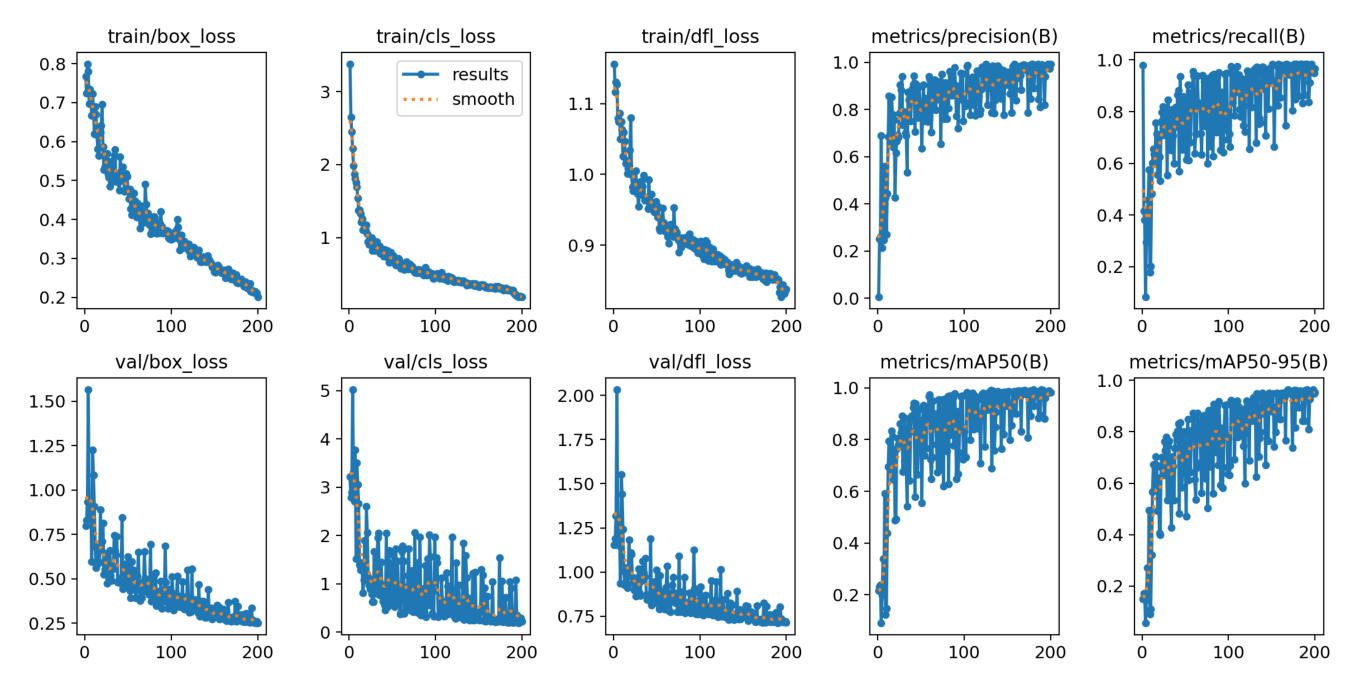

In [17]:
%matplotlib inline
img = Image.open(os.path.join(latest_run_dir, "results.png"))

plt.figure(figsize=(14, 7))
plt.imshow(img)
plt.axis("off")
plt.tight_layout()
plt.show()

In [18]:
best_model = YOLO(best_checkpoint)
metrics = best_model.val(data=fixed_yaml, imgsz=IMG_SIZE, device=DEVICE)
print(metrics)

Ultralytics 8.3.241  Python-3.11.14 torch-2.5.1 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
YOLOv12n summary (fused): 159 layers, 2,557,508 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 601.9147.1 MB/s, size: 38.5 KB)
val: Scanning D:\Daniel\.Mcast Stuffs\Level 6\3rd year\IPCV\Home Assignment\Code\chat_bot_detection_912_ai_118_non_ai_v4.yolov12\valid\labels.cache... 202 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 202/202 201.1Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 6.5it/s 2.0s0.2s
                   all        202        203      0.984      0.966       0.99      0.965
               chatgpt         63         63          1      0.986      0.995      0.966
                claude         64         64       0.96          1      0.995      0.978
                gemini         55         55      0.976      0.982      0.981      0.967
           non-chatbot     